<a href="https://colab.research.google.com/github/k6jf8wfhxh-ux/jdla-e-shikaku-study/blob/main/lecture06_exercise_answer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 第6回講義 演習

今回は，FCN（Fully Convolutional Network）を実装し，VOC2011データセットにSegmentationを実行します．



---
# Lecture 6: Exercise

This time, we will implement FCN (Fully Convolutional Network) and perform segmentation on the VOC2011 dataset.



## 目次
[【課題】FCNによる Segmentation モデルの実装と学習](#scrollTo=_pBFN4mD934j)
1. [VOC2011 データセットの読み込みと可視化](#scrollTo=d304y5XwRvGG)
2. [Preprocessing](#scrollTo=Lamm5y2CT2-W)
3. [FCN の実装](#scrollTo=R2yHHDp0VUJR)

    3.1 [backbone （事前学習モデル） の利用](#scrollTo=k4regropVqgq)

    3.2 [FCN クラスの実装](#scrollTo=KHaV8k4mXrHm)

4. [FCN の学習](#scrollTo=igJrjMAjasf_)


---
## table of contents
[[Challenge] Implementation and learning of segmentation model using FCN](#scrollTo=_pBFN4mD934j)
1. [Loading and visualizing the VOC2011 dataset](#scrollTo=d304y5XwRvGG)
2. [Preprocessing](#scrollTo=Lamm5y2CT2-W)
3. [Implementation of FCN](#scrollTo=R2yHHDp0VUJR)

    3.1 [Use of backbone (pre-trained model)](#scrollTo=k4regropVqgq)

    3.2 [Implementing the FCN class](#scrollTo=KHaV8k4mXrHm)

4. [Learning FCN](#scrollTo=igJrjMAjasf_)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
from torch import nn
from torch import optim
import torch.nn.functional as F
import torchvision
from torchvision import transforms
from torchvision.datasets import VOCSegmentation

device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
# Preparing the dataset
import os

tar_filename = "VOCtrainval_25-May-2011.tar"
root_dir = "./VOCSegmentation/2011"
devkit_path = os.path.join(root_dir, "VOCdevkit")

if os.path.exists(devkit_path):
    print("The dataset is already prepared.")
else:
    print("Download the dataset...")
    !wget https://www.robots.ox.ac.uk/~vgg/projects/pascal/VOC/voc2011/VOCtrainval_25-May-2011.tar

    print("\nDownload complete. Extracting data...")
    !mkdir -p {root_dir}
    !tar -xf {tar_filename} -C {root_dir}/

    print(f"\nThe dataset is ready. ({devkit_path})")

Download the dataset...
--2026-05-20 09:58:09--  https://www.robots.ox.ac.uk/~vgg/projects/pascal/VOC/voc2011/VOCtrainval_25-May-2011.tar
Resolving www.robots.ox.ac.uk (www.robots.ox.ac.uk)... 129.67.94.2
Connecting to www.robots.ox.ac.uk (www.robots.ox.ac.uk)|129.67.94.2|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://thor.robots.ox.ac.uk/pascal/VOC/voc2011/VOCtrainval_25-May-2011.tar [following]
--2026-05-20 09:58:11--  https://thor.robots.ox.ac.uk/pascal/VOC/voc2011/VOCtrainval_25-May-2011.tar
Resolving thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)... 129.67.95.98
Connecting to thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)|129.67.95.98|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1765686784 (1.6G) [application/octet-stream]
Saving to: ‘VOCtrainval_25-May-2011.tar’

VOCtrainval_25-May- 100%[===================>]   1.64G  20.7MB/s    in 85s     

2026-05-20 09:59:36 (19.9 MB/s) - ‘VOCtrainval_25-May-2011.tar’ 

## 【課題】FCNによる segmentation モデルの実装と学習

---
## [Challenge] Implementation and learning of segmentation model using FCN


## 1.VOC2011 データセットの読み込みと可視化

---
## 1.Loading and visualizing the VOC2011 dataset


今回の演習で扱う**VOC2011**は，以下の3用途に用いることができる，画像認識タスク用のデータセットとなっています．
- Classification
- Segmentation
- Object detection

Segmentationタスク用には，以下が提供されています．
- 入力画像
- Segmentation mask（ピクセル単位/21クラス）

VOC2011 を 前回の CIFAR-10 と同様，PyTorch でダウンロードし描画します．

以下では入力画像が左，Segmentation maskが右です．

---
The **VOC2011** used in this exercise is a dataset for image recognition tasks that can be used for the following three purposes.
- Classification
- Segmentation
- Object detection

For the Segmentation task, the following is provided:
- input image
- Segmentation mask (pixel unit/21 classes)

Download VOC2011 with PyTorch and draw it like the previous CIFAR-10.

Below, the input image is on the left and the segmentation mask is on the right.


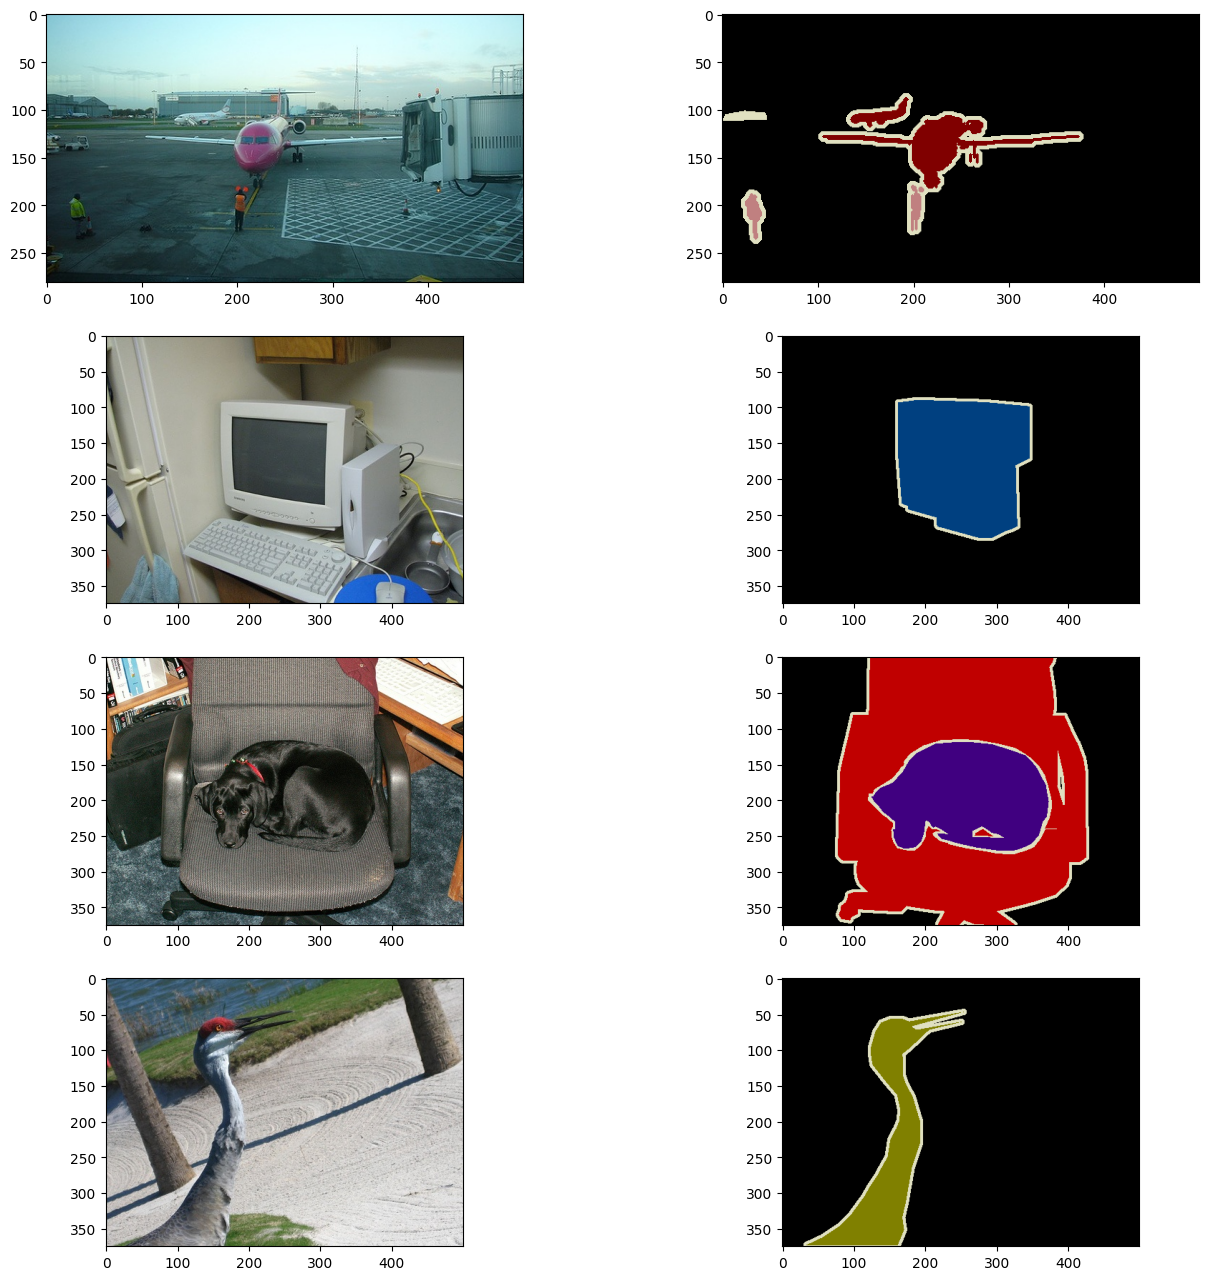

In [ ]:
# Visualization of VOC2011
train_dataset = VOCSegmentation(root="./VOCSegmentation/2011",
                                   year="2011", image_set="train", download=False)

plt.figure(figsize=(16, 16))
for i in range(4):
    image, target = train_dataset[i]
    plt.subplot(4, 2, 2*i+1)
    plt.imshow(image);
    plt.subplot(4, 2, 2*i+2)
    plt.imshow(target);

## 2.Preprocessing
VOCデータセットに以下の前処理を施します
- 入力画像，segmentation mask ともに(224, 224)へのリサイズ
- segmentation mask の境界線に対応するクラス(255)の除去
- クラスラベルのone-hot encoding（one-hotベクトル化）

前処理により，それぞれ以下のような形状になります．
- 入力画像: (3, 224, 224)
- segmentation mask: (21, 224, 224)

本演習では PyTorch に用意されている前処理の中でも画像サイズの変更 (Resize) ，PyTorch の Tensor クラスへの変更と正規化 (ToTensor) のみを利用していますが， PyTorch ではデータ拡張を含む様々な前処理が用意されています．以下の公式リファレンスを参考にしてください．
https://pytorch.org/vision/main/transforms.html#v1-api-reference  

---
## 2.Preprocessing
Perform the following preprocessing on the VOC dataset
- Resize both input image and segmentation mask to (224, 224)
- Removal of class (255) corresponding to the border of segmentation mask
- one-hot encoding of class labels (one-hot vectorization)

By preprocessing, the shapes will be as shown below.
- Input image: (3, 224, 224)
- segmentation mask: (21, 224, 224)

In this exercise, we only use image resizing (Resize), change to PyTorch's Tensor class, and normalization (ToTensor) among the preprocessing provided by PyTorch, but PyTorch provides various preprocessing including data augmentation. Please refer to the official reference below.
https://pytorch.org/vision/main/transforms.html#v1-api-reference  


In [ ]:
batch_size = 16
num_classes = 21

# Definition of preprocessing
def TargetToTensor(target):
    target = np.array(target)
    target[target > 20] = 0 # Limit labels to a total of 21 classes from 0 to 20 (delete object edges)
    target = torch.from_numpy(target).type(torch.long)
    target = F.one_hot(target, num_classes=num_classes).permute(2,0,1).type(torch.float)
    return target  # (21, 224, 224)

image_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to (224, 224)
    transforms.ToTensor(),
])
target_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Lambda(lambda target: TargetToTensor(target))
])

# Definition of dataset
train_dataset = VOCSegmentation(root="./VOCSegmentation/2011", year="2011",
                                image_set="train", download=False,
                                transform=image_transform,
                                target_transform=target_transform)
valid_dataset = VOCSegmentation(root="./VOCSegmentation/2011", year="2011",
                                image_set="val", download=False,
                                transform=image_transform,
                                target_transform=target_transform)

# Definition of dataloader
train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_dataloader = torch.utils.data.DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)

## 3.FCNの実装

---
## 3.FCN implementation


FCNは以下の二段階に分かれます．
- 既存の画像認識モデル（backbone）による特徴抽出
- ConvolutionとUpscale（Deconvolution）によるピクセル単位の予測

---
FCN is divided into the following two stages.
- Feature extraction using existing image recognition model (backbone)
- Pixel-by-pixel prediction with Convolution and Upscale (Deconvolution)


### 3.1 backbone（事前学習モデル）の利用

今回はbackboneとして以下の事前学習モデルを採用します．
- ResNet18

<img src="https://www.researchgate.net/profile/Sajid-Iqbal-13/publication/336642248/figure/fig1/AS:839151377203201@1577080687133/Original-ResNet-18-Architecture.png" alt="ResNet18" width=600 >

https://www.researchgate.net/publication/336642248_A_Deep_Learning_Approach_for_Automated_Diagnosis_and_Multi-Class_Classification_of_Alzheimer's_Disease_Stages_Using_Resting-State_fMRI_and_Residual_Neural_Networks

- GAP層（Global Average Pooling層，補足資料を参照）とFC層を外し，特徴抽出器とする


 backboneの入出力(C, H, W)は以下のようになります．
 - 入力: (3, 224, 224)
 - 出力: (512, 7, 7)


 PyTorch では様々な事前学習モデルが実装されています．タスクの複雑さやダウンストリーム（第10回を参照）との相性，利用可能な計算資源に応じて使い分けることが可能です．

 参考: https://pytorch.org/vision/main/models.html

---
### 3.1 Use of backbone (pre-learning model)

This time, we will use the following pre-trained model as the backbone.
- ResNet18

<img src="https://www.researchgate.net/profile/Sajid-Iqbal-13/publication/336642248/figure/fig1/AS:839151377203201@1577080687133/Original-ResNet-18-Architecture.png" alt="ResNet18" width=600 >

https://www.researchgate.net/publication/336642248_A_Deep_Learning_Approach_for_Automated_Diagnosis_and_Multi-Class_Classification_of_Alzheimer's_Disease_Stages_Using_Resting-State_fMRI_and_Residual_Neural_Networks

- Remove the GAP layer (Global Average Pooling layer, see supplementary material) and FC layer and use it as a feature extractor


The backbone input/output (C, H, W) is as follows.
- Input: (3, 224, 224)
- Output: (512, 7, 7)


PyTorch implements various pre-trained models. It is possible to use different methods depending on the complexity of the task, compatibility with downstream (see Part 10), and available computational resources.

Reference: https://pytorch.org/vision/main/models.html


In [ ]:
# Creating the backbone
resnet18 = torchvision.models.resnet18(pretrained=torchvision.models.ResNet18_Weights.DEFAULT)
resnet18 = nn.Sequential(*list(resnet18.children())[:-2])  # Remove GAP layer and FC layer

# Check backbone output size
dummy = torch.rand(1, 3, 224, 224)  # (B, C, H, W)
resnet18(dummy).shape

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 188MB/s]


torch.Size([1, 512, 7, 7])

### 3.2 FCNクラスの実装
FCNでは，以下の手順で予測を出力します．
- Convolution: backboneで得られた特徴をクラス数のchannelに変換
- Upscale: スケールが元画像に一致するよう変換して，予測とする

今回はそれぞれを以下のように実装します．
- Convolution: FCNhead
  - Conv2d(input_channel, input_channel//4, 3, padding=1, bias=False)
  - BatchNorm2d
  - ReLU
  - Dropout(0.1)
  - Conv2d(input_channel//4, num_classes, 1)
- Upscale: `F.interpolate(x, size=input_shape, mode='bilinear', align_corners=False)`

---
### 3.2 Implementation of FCN class
FCN outputs predictions using the following steps.
- Convolution: Convert features obtained from backbone to channels with number of classes
- Upscale: Convert the scale to match the original image and use it as a prediction

This time, we will implement each as follows.
- Convolution: FCNhead
  - Conv2d(input_channel, input_channel//4, 3, padding=1, bias=False)
  - BatchNorm2d
  - ReLU
  - Dropout(0.1)
  - Conv2d(input_channel//4, num_classes, 1)
- Upscale: `F.interpolate(x, size=input_shape, mode='bilinear', align_corners=False)`


In [ ]:
# Definition of FCN
class FCN(nn.Module):
    def __init__(self, backbone, num_classes=21):
        super(FCN, self).__init__()
        # backbone
        self.backbone = backbone
        # convolution
        self.FCNhead = nn.Sequential(nn.Conv2d(512, 128, 3, padding=1, bias=False),
                                      nn.BatchNorm2d(128),
                                      nn.ReLU(),
                                      nn.Dropout(0.1),
                                      nn.Conv2d(128, num_classes, 1))

    def forward(self, x):
        input_shape = x.shape[-2:]  # shape: (224, 224)
        x = self.backbone(x)  # WRITE ME # Processing in backbone (512, 7, 7)
        x = self.FCNhead(x)   # WRITE ME # Processing in FCNhead (21, 7 ,7)
        x = F.interpolate(    # WRITE ME  # upscale (21, 224, 224)
            x,
            size=input_shape,
            mode='bilinear',
            align_corners=False
            )
        return x

## 4.FCNの学習

---
## 4.FCN learning


以上に実装したFCNを，VOCデータセットに対して学習させます．

---
The FCN implemented above will be trained on the VOC dataset.


In [ ]:
# Creating a model
model = FCN(backbone=resnet18, num_classes=num_classes)
model.to(device)

FCN(
  (backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  

以下のように設定します．（Set as follows.）
- オプティマイザ（Optimizer）: AdamW（Adam + Weight Decay）
- 損失関数（Loss function）: BinaryCrossEntropy
- 評価指標（Evaluation metric）: mean-IoU

<img src="https://learnopencv.com/wp-content/uploads/2022/08/05-document-segmentation-IoU-Dice-concept.png" alt="miou" width=600 >

https://learnopencv.com/deep-learning-based-document-segmentation-using-semantic-segmentation-deeplabv3-on-custom-dataset/

In [ ]:
# Use the mIoU implementation linked below
# https://github.com/wkentaro/pytorch-fcn/blob/master/torchfcn/utils.py
class mIoUScore(object):
    def __init__(self, n_classes):
        self.n_classes = n_classes
        self.confusion_matrix = np.zeros((n_classes, n_classes))

    def _fast_hist(self, label_true, label_pred, n_class):
        mask = (label_true >= 0) & (label_true < n_class)
        hist = np.bincount(
            n_class * label_true[mask].astype(int) + label_pred[mask], minlength=n_class ** 2
        ).reshape(n_class, n_class)    # The ij component is the number of pixels for which the target was class i and the prediction was class j.
        return hist

    def update(self, label_trues, label_preds):
        for lt, lp in zip(label_trues, label_preds):
            self.confusion_matrix += self._fast_hist(lt.flatten(), lp.flatten(), self.n_classes)

    def get_scores(self):
        hist = self.confusion_matrix
        with np.errstate(divide='ignore', invalid='ignore'):
            iou = np.diag(hist) / (hist.sum(axis=1) + hist.sum(axis=0) - np.diag(hist))
        mean_iou = np.nanmean(iou)
        return mean_iou

    def reset(self):
        self.confusion_matrix = np.zeros((self.n_classes, self.n_classes))

In [ ]:
# Definition of optimizer, loss function, metrics
loss_fn = nn.BCEWithLogitsLoss()
metrics = mIoUScore(num_classes)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-3)

 FCNの学習を実行します．  
 google colab の無料枠で数分で終わります．

---
Execute FCN learning.
It only takes a few minutes with Google Colab's free tier.


In [ ]:
n_epochs = 5

# learning model
for epoch in range(n_epochs):
    train_losses = []
    valid_losses = []
    metrics.reset()

    model.train()
    with tqdm(total=len(train_dataloader), unit="batch") as pbar:
        pbar.set_description(f"[train] Epoch {epoch+1}/{n_epochs}")
        for image, target in train_dataloader:
            optimizer.zero_grad()
            image, target = image.to(device), target.to(device)
            output = model(image)
            loss = loss_fn(output, target)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())
            pbar.set_postfix(loss=np.array(train_losses).mean())
            pbar.update(1)

    model.eval()
    with tqdm(total=len(valid_dataloader), unit="batch") as pbar:
        pbar.set_description(f"[valid] Epoch {epoch+1}/{n_epochs}")
        for image, target in valid_dataloader:
            image, target = image.to(device), target.to(device)
            output = model(image)
            loss = loss_fn(output, target)
            valid_losses.append(loss.item())
            metrics.update(target.argmax(1).cpu().numpy(), output.argmax(1).cpu().numpy())
            pbar.set_postfix(loss=np.array(valid_losses).mean(), mIoU=metrics.get_scores())
            pbar.update(1)

[valid] Epoch 5/5: 100%|██████████| 70/70 [00:20<00:00,  3.42batch/s, loss=0.188, mIoU=0.262]


学習が終わったら，FCNによる予測を確認してみましょう．
- 左列: 元画像
- 中列: 予測
- 右列: 正解

---
After learning, let's check the predictions made by FCN.
- Left column: Original image
- Middle row: Prediction
- Right column: Correct


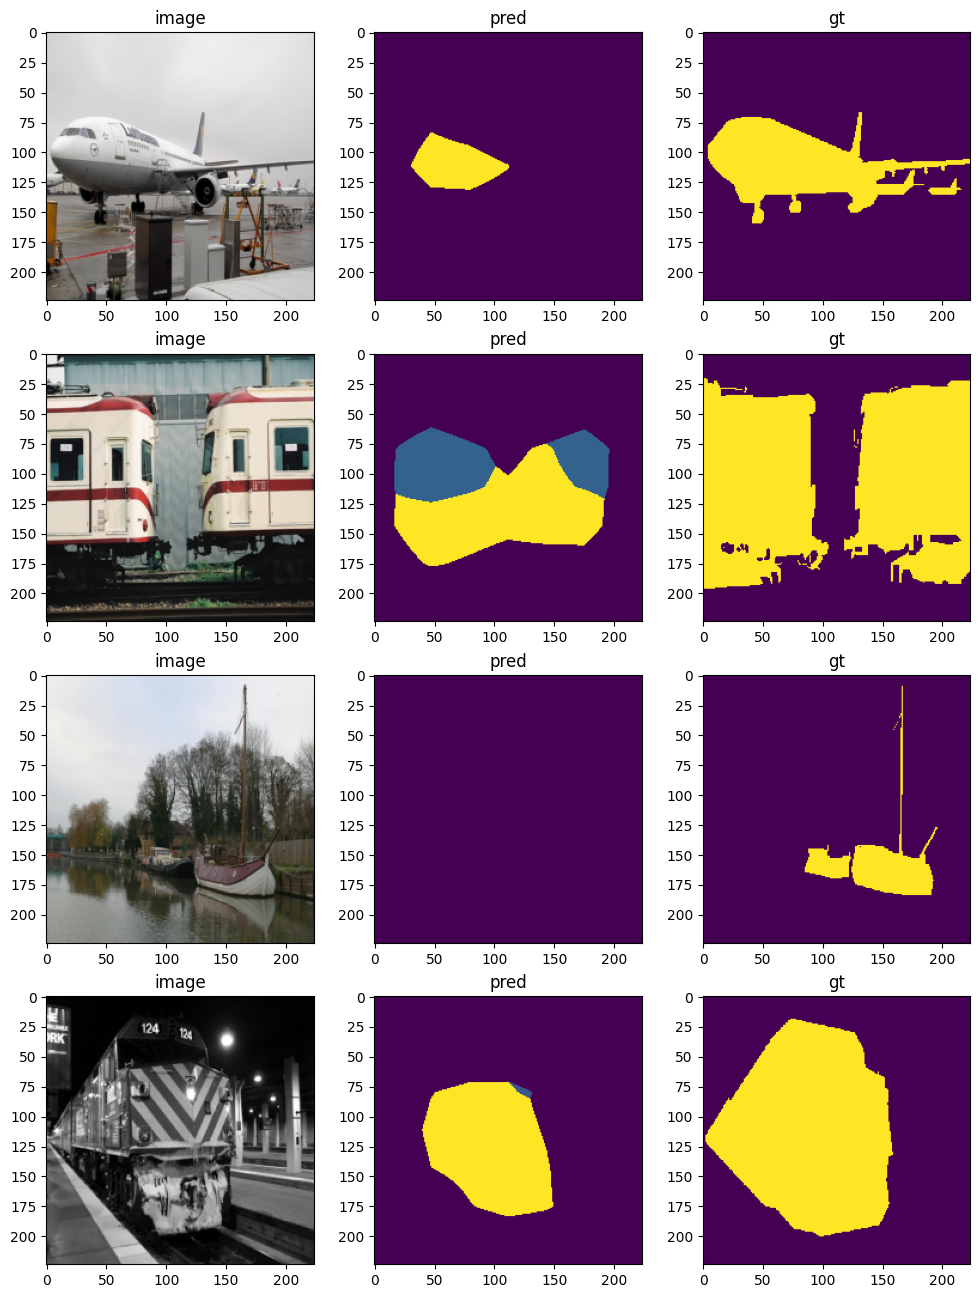

In [ ]:
# Prediction visualization
plt.figure(figsize=(12, 16))
model.eval()
for i in range(4):
    image, target = valid_dataset[i]
    pred = model(image.to(device).unsqueeze(0))
    plt.subplot(4, 3, 3*i+1)
    plt.title("image")
    plt.imshow(image.numpy().transpose(1,2,0));
    plt.subplot(4, 3, 3*i+2)
    plt.title("pred")
    plt.imshow(pred.argmax(1).cpu().numpy()[0]);
    plt.subplot(4, 3, 3*i+3)
    plt.title("gt")
    plt.imshow(target.argmax(0).cpu().numpy());

In [ ]:
class FCN(nn.Module):
    def __init__(self, backbone, num_classes=21):
        super(FCN, self).__init__()
        # backbone
        self.backbone = backbone
        # convolution
        self.FCNhead = nn.Sequential(nn.Conv2d(512, 128, 3, padding=1, bias=False),
                                      nn.BatchNorm2d(128),
                                      nn.ReLU(),
                                      nn.Dropout(0.1),
                                      nn.Conv2d(128, num_classes, 1))

    def forward(self, x):
        input_shape = x.shape[-2:]  # shape: (224, 224)
        x = self.backbone(x)  # WRITE ME # Processing in backbone (512, 7, 7)
        x = self.FCNhead(x)   # WRITE ME # Processing in FCNhead (21, 7 ,7)
        x = F.interpolate(    # WRITE ME  # upscale (21, 224, 224)
            x,
            size=input_shape,
            mode='bilinear',
            align_corners=False
            )
        return x